# 1. Coordenadas Homogêneas em 2D

## Teoria

As coordenadas homogêneas são uma extensão das coordenadas cartesianas que permitem representar transformações geométricas usando multiplicação matricial.  
Enquanto um ponto em coordenadas cartesianas é descrito como $(x, y)$, em coordenadas homogêneas ele é descrito como $(x, y, 1)$.  
A adição da terceira coordenada, chamada **coordenada homogênea**, possibilita incluir translações, rotações, escalonamentos e cisalhamentos em uma única forma matricial, utilizando matrizes $3 \times 3$.

A forma geral de um ponto em coordenadas homogêneas é:

$$
P_h =
\begin{bmatrix}
x \\
y \\
1
\end{bmatrix}
$$

O uso de coordenadas homogêneas é fundamental para computação gráfica, pois permite a composição de múltiplas transformações através de multiplicação de matrizes, garantindo eficiência computacional e consistência matemática.


In [ ]:
import numpy as np

# Definição de um ponto em coordenadas cartesianas
p_cartesiano = np.array([2, 3])

# Conversão para coordenadas homogêneas
p_homogeneo = np.append(p_cartesiano, 1)

print("Ponto cartesiano:", p_cartesiano)
print("Ponto em coordenadas homogêneas:", p_homogeneo)

Ponto cartesiano: [2 3]
Ponto em coordenadas homogêneas: [2 3 1]


## Explicação do Código

O código utiliza a biblioteca `numpy` para manipulação de vetores numéricos.  
Primeiramente, é criado um ponto cartesiano bidimensional com coordenadas \((2, 3)\), armazenado no vetor `p_cartesiano`.  
Em seguida, é realizada a conversão para coordenadas homogêneas com o uso da função `np.append`, que adiciona a coordenada \(w = 1\) ao final do vetor, resultando em `p_homogeneo = [2, 3, 1]`.  
Por fim, são impressos os dois vetores para evidenciar a diferença entre a representação cartesiana e a homogênea, destacando que a forma homogênea é compatível com operações matriciais \(3 \times 3\) utilizadas em transformações geométricas.



## Aplicação de Matrizes 3×3 em Transformações 2D

As transformações geométricas em duas dimensões podem ser representadas por matrizes $3 \times 3$ quando se utilizam coordenadas homogêneas. Essa representação permite incluir operações de translação, que não são possíveis usando apenas matrizes $2 \times 2$.

A forma geral de uma matriz de transformação afim em 2D é:

$$
\mathbf{T} =
\begin{bmatrix}
a & b & t_x \\
c & d & t_y \\
0 & 0 & 1
\end{bmatrix}
$$

- Os coeficientes $a, b, c, d$ definem a parte linear da transformação, que pode incluir rotações, escalonamentos, reflexões ou cisalhamentos.  
- Os valores $t_x$ e $t_y$ correspondem à translação nas direções $x$ e $y$.  
- A última linha fixa $[0, 0, 1]$ garante que a matriz seja adequada para pontos em coordenadas homogêneas.

A aplicação de uma transformação sobre um ponto $P_h = [x, y, 1]^T$ é feita por multiplicação matricial:

$$
P'_h = \mathbf{T} \cdot P_h
$$

O resultado $P'_h$ é outro vetor em coordenadas homogêneas. Caso seja necessário retornar ao espaço cartesiano, divide-se o resultado pelas coordenadas homogêneas $w$, obtendo:

$$
P' = \left[\frac{x'}{w}, \frac{y'}{w}\right]
$$

Essa abordagem unifica todas as transformações afins em uma única operação matricial, permitindo também compor múltiplas transformações por meio da multiplicação de matrizes.





---



## Transformações Geométricas em 2D

As transformações geométricas em 2D permitem alterar a posição, orientação, escala e forma de objetos no plano cartesiano. Quando representadas em coordenadas homogêneas, todas essas transformações podem ser expressas como multiplicação por matrizes $3 \times 3$. A seguir são apresentadas as principais transformações, suas matrizes e a interpretação de cada elemento.

### 1. Translação

A translação desloca um ponto de posição somando valores às suas coordenadas $x$ e $y$. Em coordenadas homogêneas, a translação por $(t_x, t_y)$ é representada por:

$$
\mathbf{T} =
\begin{bmatrix}
1 & 0 & t_x \\
0 & 1 & t_y \\
0 & 0 & 1
\end{bmatrix}
$$

- O $1$ na diagonal principal mantém as coordenadas originais.  
- Os termos $t_x$ e $t_y$ adicionam deslocamento ao ponto, produzindo $x' = x + t_x$ e $y' = y + t_y$.

### 2. Escalonamento

O escalonamento altera o tamanho do objeto em relação à origem. Para fatores de escala $s_x$ e $s_y$:

$$
\mathbf{S} =
\begin{bmatrix}
s_x & 0 & 0 \\
0 & s_y & 0 \\
0 & 0 & 1
\end{bmatrix}
$$

- $s_x > 1$ aumenta a largura, $0 < s_x < 1$ reduz.  
- $s_y > 1$ aumenta a altura, $0 < s_y < 1$ reduz.  
- Valores negativos produzem reflexões.

### 3. Rotação

A rotação em torno da origem por um ângulo $\theta$ é dada por:

$$
\mathbf{R} =
\begin{bmatrix}
\cos \theta & -\sin \theta & 0 \\
\sin \theta & \cos \theta & 0 \\
0 & 0 & 1
\end{bmatrix}
$$

- O cosseno e o seno formam uma matriz ortogonal que preserva distâncias.  
- O sinal negativo em $-\sin \theta$ garante rotação no sentido anti-horário no sistema cartesiano padrão.

#### Rotação em torno de um ponto arbitrário

Para rotacionar em torno de um ponto $P_c = (x_c, y_c)$, é necessário realizar uma sequência de três transformações:

1. **Transladar** o objeto de modo que $P_c$ vá para a origem:  
   $$
   \mathbf{T}_{-P_c} =
   \begin{bmatrix}
   1 & 0 & -x_c \\
   0 & 1 & -y_c \\
   0 & 0 & 1
   \end{bmatrix}
   $$

2. **Aplicar a rotação** em torno da origem usando $\mathbf{R}$.

3. **Transladar de volta** para a posição original:  
   $$
   \mathbf{T}_{P_c} =
   \begin{bmatrix}
   1 & 0 & x_c \\
   0 & 1 & y_c \\
   0 & 0 & 1
   \end{bmatrix}
   $$

A matriz composta resultante é:

$$
\mathbf{M} = \mathbf{T}_{P_c} \cdot \mathbf{R} \cdot \mathbf{T}_{-P_c}
$$

Essa composição garante que o objeto seja rotacionado em torno de $P_c$ e não em torno da origem.

### 4. Reflexão

A reflexão inverte o objeto em relação a um eixo ou linha. Exemplos comuns:

- Reflexão no eixo $x$:  
$$
\mathbf{Ref}_x =
\begin{bmatrix}
1 & 0 & 0 \\
0 & -1 & 0 \\
0 & 0 & 1
\end{bmatrix}
$$

- Reflexão no eixo $y$:  
$$
\mathbf{Ref}_y =
\begin{bmatrix}
-1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1
\end{bmatrix}
$$

Os valores negativos invertem o sinal da coordenada correspondente.

### 5. Cisalhamento (Shear)

O cisalhamento distorce o objeto inclinando seus lados. Existem dois casos principais:

- Cisalhamento horizontal, com fator $sh_x$:  
$$
\mathbf{Sh}_x =
\begin{bmatrix}
1 & sh_x & 0 \\
0 & 1 & 0 \\
0 & 0 & 1
\end{bmatrix}
$$

- Cisalhamento vertical, com fator $sh_y$:  
$$
\mathbf{Sh}_y =
\begin{bmatrix}
1 & 0 & 0 \\
sh_y & 1 & 0 \\
0 & 0 & 1
\end{bmatrix}
$$

Os termos $sh_x$ e $sh_y$ adicionam proporção de uma coordenada sobre a outra, criando o efeito de inclinação.

---

Todas essas transformações podem ser combinadas multiplicando-se suas matrizes na ordem desejada, formando uma única matriz composta que realiza todas as operações de uma só vez.





---



# Exemplos Numéricos de Transformações 2D em Coordenadas Homogêneas

## Figura inicial

Considere o quadrado de lado 2, centrado em $(2, 2)$, com vértices na ordem anti-horária:
$$
P_1=(1,1),\quad P_2=(3,1),\quad P_3=(3,3),\quad P_4=(1,3).
$$
Em homogêneas:
$$
P_i^h=\begin{bmatrix}x_i\\y_i\\1\end{bmatrix}.
$$
Convenção utilizada. Vetores coluna. Aplicação como $P'_h=\mathbf{M}P_h$.

---

## Translação por $(t_x,t_y)=(2,-1)$

Matriz
$$
\mathbf{T}=
\begin{bmatrix}
1&0&t_x\\
0&1&t_y\\
0&0&1
\end{bmatrix}=
\begin{bmatrix}
1&0&2\\
0&1&-1\\
0&0&1
\end{bmatrix}.
$$

Cálculo exemplo para $P_1$
$$
P_1'^h=\mathbf{T}\,P_1^h=
\begin{bmatrix}
1&0&2\\
0&1&-1\\
0&0&1
\end{bmatrix}
\begin{bmatrix}
1\\1\\1
\end{bmatrix}
=
\begin{bmatrix}
3\\0\\1
\end{bmatrix}\Rightarrow P_1'=(3,0).
$$

Resultados
$$
\begin{aligned}
P_1'&=(3,0),&
P_2'&=(5,0),&
P_3'&=(5,2),&
P_4'&=(3,2).
\end{aligned}
$$

---

## Escalonamento em torno da origem com $s_x=2$ e $s_y=0{,}5$

Matriz
$$
\mathbf{S}=
\begin{bmatrix}
s_x&0&0\\
0&s_y&0\\
0&0&1
\end{bmatrix}=
\begin{bmatrix}
2&0&0\\
0&0{,}5&0\\
0&0&1
\end{bmatrix}.
$$

Cálculo exemplo para $P_2$
$$
P_2'^h=\mathbf{S}\,P_2^h=
\begin{bmatrix}
2&0&0\\
0&0{,}5&0\\
0&0&1
\end{bmatrix}
\begin{bmatrix}
3\\1\\1
\end{bmatrix}
=
\begin{bmatrix}
6\\0{,}5\\1
\end{bmatrix}\Rightarrow P_2'=(6,0{,}5).
$$

Resultados
$$
\begin{aligned}
P_1'&=(2,0{,}5),&
P_2'&=(6,0{,}5),&
P_3'&=(6,1{,}5),&
P_4'&=(2,1{,}5).
\end{aligned}
$$

---

## Rotação de $90^\circ$ anti-horária em torno da origem

Para $\theta=90^\circ$ tem-se $\cos\theta=0$ e $\sin\theta=1$.

Matriz
$$
\mathbf{R}=
\begin{bmatrix}
\cos\theta&-\sin\theta&0\\
\sin\theta&\cos\theta&0\\
0&0&1
\end{bmatrix}=
\begin{bmatrix}
0&-1&0\\
1&0&0\\
0&0&1
\end{bmatrix}.
$$

Cálculo exemplo para $P_3$
$$
P_3'^h=\mathbf{R}\,P_3^h=
\begin{bmatrix}
0&-1&0\\
1&0&0\\
0&0&1
\end{bmatrix}
\begin{bmatrix}
3\\3\\1
\end{bmatrix}
=
\begin{bmatrix}
-3\\3\\1
\end{bmatrix}\Rightarrow P_3'=(-3,3).
$$

Resultados
$$
\begin{aligned}
P_1'&=(-1,1),&
P_2'&=(-1,3),&
P_3'&=(-3,3),&
P_4'&=(-3,1).
\end{aligned}
$$

Observação. Para rotacionar em torno de um ponto $C=(x_c,y_c)$, utiliza-se $\mathbf{M}=\mathbf{T}_{C}\,\mathbf{R}\,\mathbf{T}_{-C}$.

---

## Reflexão em relação ao eixo $x$

Matriz
$$
\mathbf{Ref}_x=
\begin{bmatrix}
1&0&0\\
0&-1&0\\
0&0&1
\end{bmatrix}.
$$

Cálculo exemplo para $P_4$
$$
P_4'^h=\mathbf{Ref}_x\,P_4^h=
\begin{bmatrix}
1&0&0\\
0&-1&0\\
0&0&1
\end{bmatrix}
\begin{bmatrix}
1\\3\\1
\end{bmatrix}
=
\begin{bmatrix}
1\\-3\\1
\end{bmatrix}\Rightarrow P_4'=(1,-3).
$$

Resultados
$$
\begin{aligned}
P_1'&=(1,-1),&
P_2'&=(3,-1),&
P_3'&=(3,-3),&
P_4'&=(1,-3).
\end{aligned}
$$

---

## Cisalhamento horizontal com fator $sh_x=1$

Matriz
$$
\mathbf{Sh}_x=
\begin{bmatrix}
1&sh_x&0\\
0&1&0\\
0&0&1
\end{bmatrix}=
\begin{bmatrix}
1&1&0\\
0&1&0\\
0&0&1
\end{bmatrix}.
$$

Cálculo exemplo para $P_2$
$$
P_2'^h=\mathbf{Sh}_x\,P_2^h=
\begin{bmatrix}
1&1&0\\
0&1&0\\
0&0&1
\end{bmatrix}
\begin{bmatrix}
3\\1\\1
\end{bmatrix}
=
\begin{bmatrix}
4\\1\\1
\end{bmatrix}\Rightarrow P_2'=(4,1).
$$

Resultados
$$
\begin{aligned}
P_1'&=(2,1),&
P_2'&=(4,1),&
P_3'&=(6,3),&
P_4'&=(4,3).
\end{aligned}
$$

---

## Composição de transformações em sequência

Objetivo. Aplicar na ordem definida a seguir, sobre o quadrado original. Primeiro transladar por $(1,2)$. Em seguida rotacionar $90^\circ$ anti-horária em torno da origem. Por fim escalonar com $s_x=0{,}5$ e $s_y=2$, em torno da origem.

Matrizes individuais
$$
\mathbf{T}=
\begin{bmatrix}
1&0&1\\
0&1&2\\
0&0&1
\end{bmatrix},\quad
\mathbf{R}=
\begin{bmatrix}
0&-1&0\\
1&0&0\\
0&0&1
\end{bmatrix},\quad
\mathbf{S}=
\begin{bmatrix}
0{,}5&0&0\\
0&2&0\\
0&0&1
\end{bmatrix}.
$$

Matriz composta. A convenção $P'_h=\mathbf{M}P_h$ implica $\mathbf{M}=\mathbf{S}\,\mathbf{R}\,\mathbf{T}$ para respeitar a ordem desejada.
$$
\mathbf{R}\mathbf{T}=
\begin{bmatrix}
0&-1&-2\\
1&0&1\\
0&0&1
\end{bmatrix},
\quad
\mathbf{M}=\mathbf{S}(\mathbf{R}\mathbf{T})=
\begin{bmatrix}
0&-0{,}5&-1\\
2&0&2\\
0&0&1
\end{bmatrix}.
$$

Aplicação em cada vértice

Para $P_1=(1,1)$
$$
P_1'^h=\mathbf{M}
\begin{bmatrix}
1\\1\\1
\end{bmatrix}
=
\begin{bmatrix}
0\cdot1+(-0{,}5)\cdot1+(-1)\cdot1\\
2\cdot1+0\cdot1+2\cdot1\\
1
\end{bmatrix}
=
\begin{bmatrix}
-1{,}5\\
4\\
1
\end{bmatrix}\Rightarrow P_1'=(-1{,}5,\,4).
$$

Resultados para todos os vértices
$$
\begin{aligned}
P_1'&=(-1{,}5,\,4),&
P_2'&=(-1{,}5,\,8),&
P_3'&=(-2{,}5,\,8),&
P_4'&=(-2{,}5,\,4).
\end{aligned}
$$

Observações conceituais finais

A ordem de multiplicação influencia o resultado, pois a composição de transformações afins não é comutativa. A normalização por $w$ é trivial neste conjunto, pois $w=1$ é preservado em transformações afins. Para rotações ou escalonamentos em torno de um ponto $C$ diferente da origem, utiliza-se o padrão $\mathbf{M}=\mathbf{T}_{C}\,\mathbf{L}\,\mathbf{T}_{-C}$, em que $\mathbf{L}$ é a transformação linear desejada.

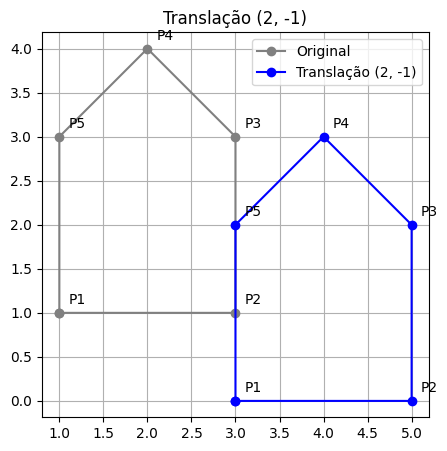

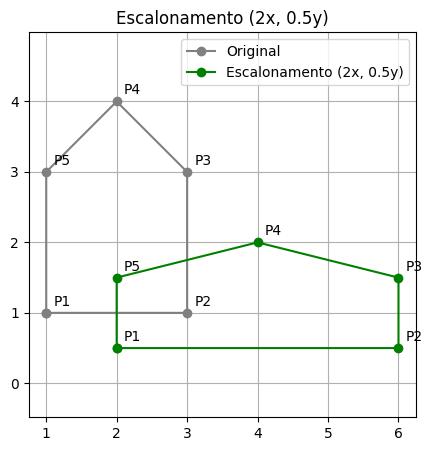

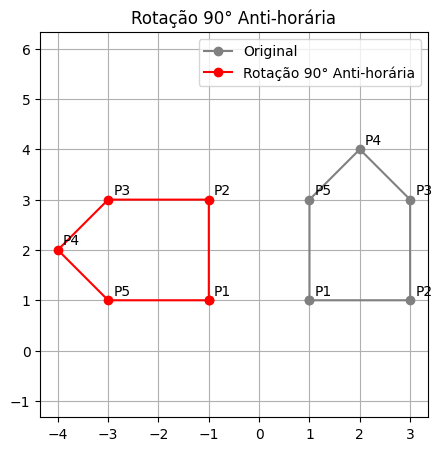

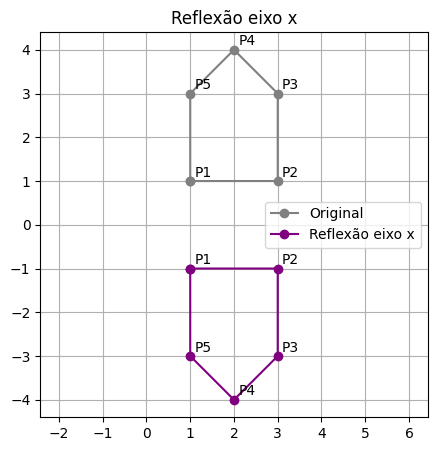

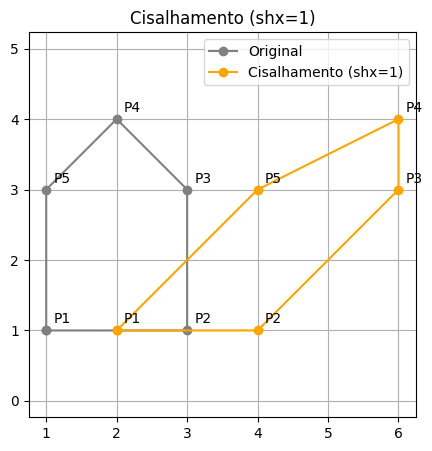

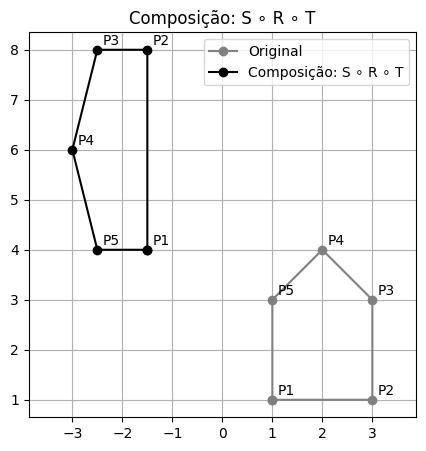

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, floatmode="maxprec_equal")

# -----------------------------------------
# Quadrado inicial (vértices em ordem anti-horária)
P = np.array([
    [1., 3., 3., 2., 1.],
    [1., 1., 3., 4., 3.],
    [1., 1., 1., 1., 1.]
])

def plot_square(P, title, color='b'):
    """Plota um quadrado a partir da matriz de pontos homogêneos P."""
    x = np.append(P[0, :], P[0, 0])  # fecha o quadrado
    y = np.append(P[1, :], P[1, 0])
    plt.plot(x, y, 'o-', color=color, label=title)
    for i in range(P.shape[1]):
        plt.text(P[0, i] + 0.1, P[1, i] + 0.1, f"P{i+1}")

def apply_and_plot(name, M, P, color):
    """Aplica transformação M e plota resultado."""
    Pp = M @ P
    plt.figure(figsize=(5, 5))
    plot_square(P, "Original", color='gray')
    plot_square(Pp, name, color=color)
    plt.title(name)
    plt.axis('equal')
    plt.grid(True)
    plt.legend()
    plt.show()
    return Pp

# 1) Translação
T = np.array([
    [1., 0.,  2.],
    [0., 1., -1.],
    [0., 0.,  1.]
])
P_T = apply_and_plot("Translação (2, -1)", T, P, 'blue')

# 2) Escalonamento
S = np.array([
    [2., 0., 0.],
    [0., 0.5, 0.],
    [0., 0., 1.]
])
P_S = apply_and_plot("Escalonamento (2x, 0.5y)", S, P, 'green')

# 3) Rotação 90°
R = np.array([
    [0., -1., 0.],
    [1.,  0., 0.],
    [0.,  0., 1.]
])
P_R = apply_and_plot("Rotação 90° Anti-horária", R, P, 'red')

# 4) Reflexão eixo x
Refx = np.array([
    [1.,  0., 0.],
    [0., -1., 0.],
    [0.,  0., 1.]
])
P_Ref = apply_and_plot("Reflexão eixo x", Refx, P, 'purple')

# 5) Cisalhamento
Shx = np.array([
    [1., 1., 0.],
    [0., 1., 0.],
    [0., 0., 1.]
])
P_Shx = apply_and_plot("Cisalhamento (shx=1)", Shx, P, 'orange')

# 6) Composição: T(1,2) -> R(90°) -> S(0.5,2)
T2 = np.array([
    [1., 0., 1.],
    [0., 1., 2.],
    [0., 0., 1.]
])
Sfinal = np.array([
    [0.5, 0., 0.],
    [0., 2., 0.],
    [0., 0., 1.]
])
M = Sfinal @ (R @ T2)
P_M = apply_and_plot("Composição: S ∘ R ∘ T", M, P, 'black')


## Explicação detalhada do código de plotagem

### Objetivo geral
O script ilustra, de forma incremental, o efeito de diferentes transformações afins em 2D sobre um quadrado. Cada transformação é aplicada por multiplicação de uma matriz \(3 \times 3\) em coordenadas homogêneas e o resultado é visualizado com `matplotlib` no mesmo gráfico do polígono original.

### Representação da figura
O quadrado inicial é definido pelos vértices \(P_1=(1,1)\), \(P_2=(3,1)\), \(P_3=(3,3)\), \(P_4=(1,3)\). A matriz `P` possui dimensão \(3 \times 4\) e armazena os pontos em coordenadas homogêneas, onde cada coluna é um vértice \([x, y, 1]^T\). Essa organização permite aplicar uma única multiplicação matricial para transformar todos os vértices simultaneamente.

### Impressão e precisão numérica
A chamada `np.set_printoptions(suppress=True, floatmode="maxprec_equal")` ajusta a forma de exibição de números, suprimindo notação científica desnecessária e mantendo precisão consistente. Não altera cálculos, apenas a forma de impressão em saídas.

### Função `plot_square(P, title, color)`
Esta função recebe a matriz de pontos homogêneos `P`, um título e uma cor para plotagem.
1. Extrai os vetores `x` e `y` de `P` e repete o primeiro vértice ao final para fechar o polígono.
2. Plota o contorno com marcadores e linhas, atribuindo rótulo para legenda.
3. Anota cada vértice com `plt.text`, deslocando levemente a posição do texto para facilitar a leitura.
4. Não realiza normalização de \(w\) pois, para transformações afins, a terceira coordenada permanece igual a 1.

### Função `apply_and_plot(name, M, P, color)`
Esta função aplica a transformação `M` sobre `P` e exibe o resultado em um novo gráfico.
1. Calcula `Pp = M @ P`, onde `@` indica o produto matricial. A multiplicação é feita no espaço homogêneo e retorna `Pp` com dimensão \(3 \times 4\).
2. Cria uma nova figura, plota o polígono original em cinza e o polígono transformado com a cor fornecida. A sobreposição no mesmo gráfico facilita a comparação visual.
3. Define `plt.axis('equal')` para preservar a proporção entre eixos, evitando distorções visuais.
4. Ativa grade e legenda para leitura mais clara e chama `plt.show()` para exibir a figura daquele passo.
5. Retorna `Pp` para uso posterior, caso se deseje encadear transformações adicionais.

### Matrizes de transformação utilizadas
As matrizes seguem a forma homogênea padrão
\[
\begin{bmatrix}
a & b & t_x\\
c & d & t_y\\
0 & 0 & 1
\end{bmatrix},
\]
em que a submatriz \(2 \times 2\) representa a parte linear e a última coluna representa a translação. No código são usadas:
- Translação \((2,-1)\): desloca o quadrado somando \(t_x=2\) e \(t_y=-1\).
- Escalonamento na origem com \(s_x=2\) e \(s_y=0{,}5\): altera a escala separadamente nos eixos.
- Rotação de \(90^\circ\) anti-horária na origem: utiliza a matriz canônica com \(\cos 90^\circ=0\) e \(\sin 90^\circ=1\).
- Reflexão no eixo \(x\): inverte o sinal da coordenada \(y\).
- Cisalhamento horizontal com \(sh_x=1\): inclina o polígono adicionando uma fração de \(y\) à coordenada \(x\).

Cada uma dessas matrizes é passada a `apply_and_plot`, que produz uma figura com o original e o transformado.

### Composição de transformações
A composição final obedece a ordem definida no enunciado. Primeiro traduz \((1,2)\), depois rotaciona \(90^\circ\) e por fim aplica escalonamento com \(s_x=0{,}5\) e \(s_y=2\). No formalismo \(P' = M P\), a matriz composta é
\[
M = S \cdot R \cdot T,
\]
o que implica que a transformação mais à direita é aplicada primeiro. O código implementa exatamente essa ordem com `M = Sfinal @ (R @ T2)`. Essa organização reforça a não comutatividade de transformações afins: trocar a ordem altera o resultado geométrico.

### Aspectos visuais e leitura dos gráficos
Cada chamada de `apply_and_plot` abre uma figura independente que contém dois polígonos. O título indica a transformação aplicada. A legenda diferencia original e transformado. Os rótulos \(P_1, P_2, P_3, P_4\) aparecem para auxiliar a comparação de vértices antes e depois. A escolha de `axis('equal')` evita interpretações equivocadas de alongamentos ou compressões que poderiam surgir de escalas diferentes nos eixos.

### Observações finais
Como as transformações exibidas são afins, a coordenada homogênea \(w\) permanece igual a 1, dispensando normalização explícita. Em aplicações que envolvem projeções, é necessária a normalização por \(w\) após a multiplicação. A estrutura matricial adotada facilita a extensão do código para rotações ou escalonamentos em torno de pontos arbitrários, bastando compor com pares de translações apropriados.




---



## Composição e Ordem de Transformações

### Conceito de composição
Transformações afins em coordenadas homogêneas são representadas por multiplicação de matrizes. Quando se aplicam várias transformações em sequência, é possível **compor** essas transformações em uma única matriz, multiplicando-as na ordem correta. Essa abordagem é fundamental para eficiência em computação gráfica, pois reduz múltiplas operações ponto a ponto a uma única multiplicação por vértice.

Seja um ponto $P_h$ e duas transformações $\mathbf{A}$ e $\mathbf{B}$:
$$
P'_h = \mathbf{B}(\mathbf{A}P_h) = (\mathbf{B}\mathbf{A})P_h.
$$
A matriz composta $\mathbf{M} = \mathbf{B}\mathbf{A}$ aplica primeiro $\mathbf{A}$ e depois $\mathbf{B}$.  
**A ordem importa:** multiplicação de matrizes não é comutativa, ou seja, em geral $\mathbf{B}\mathbf{A} \neq \mathbf{A}\mathbf{B}$.

### Ordem de aplicação: direita para esquerda
O vetor coluna está sempre à direita na multiplicação. Assim, a transformação mais próxima do vetor é aplicada primeiro. Por exemplo:
$$
P'_h = \mathbf{S}\mathbf{R}\mathbf{T}P_h
$$
significa:
1. **Primeiro:** aplicar translação $\mathbf{T}$.
2. **Depois:** aplicar rotação $\mathbf{R}$.
3. **Por último:** aplicar escalonamento $\mathbf{S}$.

Trocar a ordem gera resultado diferente. Exemplo: escalar e depois transladar produz pontos finais diferentes de transladar e depois escalar, pois a translação também é multiplicada pelo fator de escala se vier antes.

### Interpretação geométrica
- **Transformações lineares (R, S, Shear)** afetam direções, ângulos e escalas.
- **Translações** afetam posição absoluta do objeto.  
Quando uma transformação linear vem **antes** da translação, o vetor de translação também é transformado.  
Quando a translação vem **depois**, ela desloca o objeto já transformado, sem alterar direção ou magnitude da translação.

### Exemplo comparativo
Considere um ponto $P = (1,1)$, uma translação $T_x=2$ e uma escala $s_x=2$:

1. **Escala seguida de translação:**
$$
P' = \mathbf{T}\mathbf{S}P =
\begin{bmatrix}
1 & 0 & 2\\
0 & 1 & 0\\
0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
2 & 0 & 0\\
0 & 2 & 0\\
0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
1\\1\\1
\end{bmatrix}
=
\begin{bmatrix}
4\\2\\1
\end{bmatrix} \Rightarrow (4,2).
$$

2. **Translação seguida de escala:**
$$
P'' = \mathbf{S}\mathbf{T}P =
\begin{bmatrix}
2 & 0 & 0\\
0 & 2 & 0\\
0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
1 & 0 & 2\\
0 & 1 & 0\\
0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
1\\1\\1
\end{bmatrix}
=
\begin{bmatrix}
6\\2\\1
\end{bmatrix} \Rightarrow (6,2).
$$

O resultado final é diferente, evidenciando a **não comutatividade** da operação.

### Benefícios da matriz composta
- **Eficiência:** em uma cena com milhares de vértices, aplicar uma única multiplicação por vértice é mais rápido do que várias multiplicações sucessivas.
- **Organização:** facilita reuso em animações e hierarquias de objetos (por exemplo, um braço conectado a um corpo).
- **Consistência:** garante que todos os vértices recebam a mesma sequência de transformações, evitando distorções.

### Conclusão
A composição de transformações é um conceito central na computação gráfica. Entender a ordem correta de aplicação é essencial para controlar corretamente a posição, escala e orientação dos objetos. Em pipelines gráficos, é comum construir uma matriz global acumulando todas as transformações necessárias antes de enviar os vértices para o processador gráfico.




Escala -> Translação (M = T @ S)
P1' = (4.0, 2.0)
P2' = (8.0, 2.0)
P3' = (8.0, 6.0)
P4' = (4.0, 6.0)

Translação -> Escala (M = S @ T)
P1' = (6.0, 2.0)
P2' = (10.0, 2.0)
P3' = (10.0, 6.0)
P4' = (6.0, 6.0)


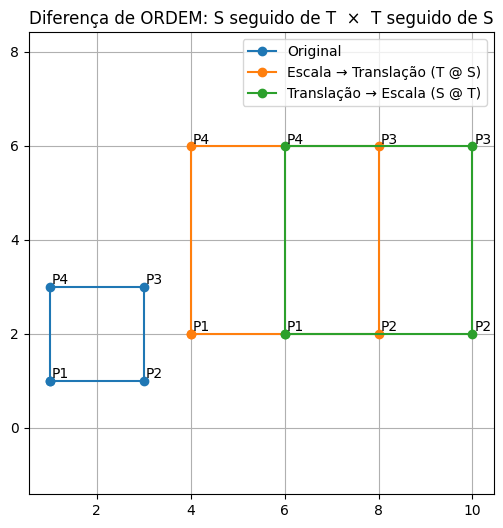


Rotação → Translação (M = T @ R)
P1' = (1.0, 1.0)
P2' = (1.0, 3.0)
P3' = (-1.0, 3.0)
P4' = (-1.0, 1.0)

Translação → Rotação (M = R @ T)
P1' = (-1.0, 3.0)
P2' = (-1.0, 5.0)
P3' = (-3.0, 5.0)
P4' = (-3.0, 3.0)


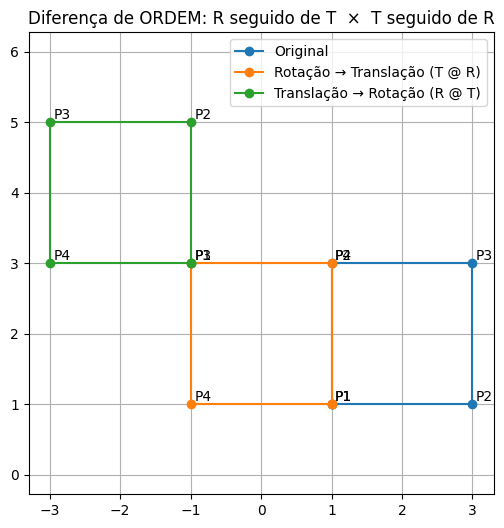

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, floatmode="maxprec_equal")

# -----------------------------------------
# Quadrado inicial (vértices em ordem anti-horária)
# P1=(1,1), P2=(3,1), P3=(3,3), P4=(1,3)
# Matriz 3x4: cada coluna é um ponto homogêneo [x, y, 1]^T
P = np.array([
    [1., 3., 3., 1.],
    [1., 1., 3., 3.],
    [1., 1., 1., 1.]
])

def plot_square(P, label=None, style='o-'):
    """Plota um polígono fechado definido pelas colunas de P (homogêneas)."""
    x = np.append(P[0, :], P[0, 0])  # fecha o polígono
    y = np.append(P[1, :], P[1, 0])
    plt.plot(x, y, style, label=label)
    for i in range(P.shape[1]):
        plt.text(P[0, i] + 0.05, P[1, i] + 0.05, f"P{i+1}")

def transform(M, P):
    """Aplica transformação homogênea M aos pontos P (homogêneos)."""
    return M @ P

def print_vertices(title, P):
    """Imprime vértices em coordenadas cartesianas."""
    cart = (P[:2, :] / P[2, :]).T
    print(f"\n{title}")
    for i, (x, y) in enumerate(cart, start=1):
        print(f"P{i}' = ({x}, {y})")


# -----------------------------------------
# Par de transformações para comparar ORDEM:
# Escala (sx, sy) seguida de Translação (tx, ty)    -> M_TS = T @ S
# Translação (tx, ty) seguida de Escala (sx, sy)    -> M_ST = S @ T
sx, sy = 2.0, 2.0
tx, ty = 2.0, 0.0

S = np.array([
    [sx, 0., 0.],
    [0., sy, 0.],
    [0., 0., 1.]
])

T = np.array([
    [1., 0., tx],
    [0., 1., ty],
    [0., 0., 1.]
])

# Matrizes compostas
M_TS = T @ S   # Escala -> Translação
M_ST = S @ T   # Translação -> Escala

# Aplicações
P_TS = transform(M_TS, P)
P_ST = transform(M_ST, P)

# Impressão dos vértices para comparação
print_vertices("Escala -> Translação (M = T @ S)", P_TS)
print_vertices("Translação -> Escala (M = S @ T)", P_ST)

# -----------------------------------------
# Plot: comparação em um único gráfico
plt.figure(figsize=(6, 6))
plot_square(P, label="Original", style='o-')
plot_square(P_TS, label="Escala → Translação (T @ S)", style='o-')
plot_square(P_ST, label="Translação → Escala (S @ T)", style='o-')
plt.title("Diferença de ORDEM: S seguido de T  ×  T seguido de S")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------------------
# Extra: comparar outro par (Rotação e Translação) para reforçar
# Rotação de 90° anti-horária
R90 = np.array([
    [0., -1., 0.],
    [1.,  0., 0.],
    [0.,  0., 1.]
])

# Matrizes compostas
# R -> T  vs  T -> R
M_RT = T @ R90   # Rotação -> Translação
M_TR = R90 @ T   # Translação -> Rotação

P_RT = transform(M_RT, P)
P_TR = transform(M_TR, P)

print_vertices("Rotação → Translação (M = T @ R)", P_RT)
print_vertices("Translação → Rotação (M = R @ T)", P_TR)

plt.figure(figsize=(6, 6))
plot_square(P, label="Original", style='o-')
plot_square(P_RT, label="Rotação → Translação (T @ R)", style='o-')
plot_square(P_TR, label="Translação → Rotação (R @ T)", style='o-')
plt.title("Diferença de ORDEM: R seguido de T  ×  T seguido de R")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()


## Explicação detalhada do código de comparação de ordem de transformações

### Objetivo
O código demonstra que a ordem de aplicação das transformações afins em 2D influencia o resultado final. Para isso, compara:
1. Escalonamento seguido de translação versus translação seguida de escalonamento.
2. Rotação seguida de translação versus translação seguida de rotação.

Os resultados são exibidos numericamente e graficamente, sobrepondo os polígonos transformados para facilitar a visualização da diferença.

### Definição do quadrado
A matriz `P` contém os quatro vértices do quadrado original em coordenadas homogêneas, com cada coluna representando um vértice na forma \([x, y, 1]^T\). Essa estrutura permite aplicar transformações a todos os vértices de uma vez, via produto matricial.

### Funções auxiliares
- **`plot_square`**: plota o quadrado conectando os pontos em ordem anti-horária, fechando o polígono ao repetir o primeiro ponto no final. Os rótulos \(P_1, P_2, P_3, P_4\) são inseridos próximos aos vértices para facilitar a identificação.
- **`transform`**: aplica a multiplicação matricial \(\mathbf{M}P\) e retorna os novos pontos em homogêneas.
- **`print_vertices`**: normaliza os resultados dividindo por \(w\) (no caso de transformações afins, \(w=1\)), e imprime os vértices resultantes em coordenadas cartesianas para inspeção numérica.

### Matrizes de transformação
São definidas:
- **Matriz de escala** `S`: aumenta o tamanho do quadrado em \(s_x = s_y = 2\), dobrando a largura e a altura.
- **Matriz de translação** `T`: desloca todos os pontos \(2\) unidades no eixo \(x\).

As composições são:
- **M_TS = T @ S**: aplica primeiro `S` (escala) e depois `T` (translação).
- **M_ST = S @ T**: aplica primeiro `T` (translação) e depois `S` (escala).

O uso de `@` indica multiplicação matricial no `numpy`, e a convenção `P' = M P` garante que a transformação mais à direita seja aplicada primeiro.

### Comparação gráfica
Um único gráfico é gerado para mostrar:
- O quadrado original.
- O quadrado após escala seguida de translação.
- O quadrado após translação seguida de escala.

O título e a legenda deixam explícita a ordem de cada operação. A função `plt.axis('equal')` assegura que os eixos tenham a mesma escala, evitando distorções visuais.

### Comparação adicional: rotação e translação
Para reforçar o conceito, o código repete o procedimento usando uma rotação de \(90^\circ\) anti-horária:
- **M_RT = T @ R90**: aplica primeiro rotação, depois translação.
- **M_TR = R90 @ T**: aplica primeiro translação, depois rotação.

A diferença é evidente nos gráficos: no primeiro caso, o quadrado é rotacionado em torno da origem e então deslocado; no segundo caso, o quadrado é deslocado e depois rotacionado, o que altera sua posição final de forma distinta.

### Conclusão
O código mostra que a multiplicação de matrizes de transformação é não comutativa: trocar a ordem das operações gera resultados diferentes. O uso de gráficos e impressão dos vértices ajuda a visualizar o impacto prático da escolha da ordem, conceito central no pipeline de transformações em computação gráfica.




---



## Rotação em torno de um ponto arbitrário

### Motivação
A matriz de rotação padrão gira pontos em torno da origem $(0,0)$. Para girar em torno de um ponto $C = (x_c, y_c)$ qualquer, é necessário **reposicionar o sistema de coordenadas** de forma que $C$ passe a ser a origem, aplicar a rotação, e depois retornar ao sistema original. Essa sequência é conhecida como **translada–rota–translada de volta**.

### Matriz composta
Sejam:
- $\mathbf{T}_{-C}$: translação que leva $C$ para a origem.
- $\mathbf{R}_\theta$: rotação de ângulo $\theta$ em torno da origem.
- $\mathbf{T}_{C}$: translação que leva a origem de volta para $C$.

A matriz composta que realiza a rotação em torno de $C$ é:
$$
\mathbf{M} = \mathbf{T}_C \cdot \mathbf{R}_\theta \cdot \mathbf{T}_{-C}
$$

### Construção passo a passo
1. **Translação para a origem**
$$
\mathbf{T}_{-C} =
\begin{bmatrix}
1 & 0 & -x_c \\
0 & 1 & -y_c \\
0 & 0 & 1
\end{bmatrix}
$$

2. **Rotação na origem**
$$
\mathbf{R}_\theta =
\begin{bmatrix}
\cos \theta & -\sin \theta & 0 \\
\sin \theta & \cos \theta & 0 \\
0 & 0 & 1
\end{bmatrix}
$$

3. **Translação de volta**
$$
\mathbf{T}_{C} =
\begin{bmatrix}
1 & 0 & x_c \\
0 & 1 & y_c \\
0 & 0 & 1
\end{bmatrix}
$$

Multiplicando estas matrizes obtém-se a matriz única $\mathbf{M}$ que aplica a rotação no ponto desejado.

### Exemplo numérico

**Problema:**  
Rotacionar o quadrado com vértices  
$$
P_1=(1,1),\; P_2=(3,1),\; P_3=(3,3),\; P_4=(1,3)
$$  
em torno do ponto $C=(3,1)$ por um ângulo $\theta = 90^\circ$ anti-horário.

#### Passo 1 – Transladar para que $C$ vá para a origem
$$
\mathbf{T}_{-C} =
\begin{bmatrix}
1 & 0 & -3 \\
0 & 1 & -1 \\
0 & 0 & 1
\end{bmatrix}
$$

Aplicando em $P_3=(3,3)$:
$$
P_3' = \mathbf{T}_{-C} P_3 =
\begin{bmatrix}
0 \\ 2 \\ 1
\end{bmatrix}
$$

O ponto agora está relativo ao sistema com origem em $C$.

#### Passo 2 – Aplicar rotação de $90^\circ$
Para $\theta = 90^\circ$: $\cos\theta = 0$, $\sin\theta = 1$.
$$
\mathbf{R}_{90} =
\begin{bmatrix}
0 & -1 & 0 \\
1 &  0 & 0 \\
0 &  0 & 1
\end{bmatrix}
$$

Aplicando em $P_3'$:
$$
P_3'' = \mathbf{R}_{90} P_3' =
\begin{bmatrix}
-2 \\ 0 \\ 1
\end{bmatrix}
$$

#### Passo 3 – Transladar de volta
$$
\mathbf{T}_C =
\begin{bmatrix}
1 & 0 & 3 \\
0 & 1 & 1 \\
0 & 0 & 1
\end{bmatrix}
$$

Aplicando:
$$
P_3''' = \mathbf{T}_C P_3'' =
\begin{bmatrix}
1 \\ 1 \\ 1
\end{bmatrix}
$$

Portanto, após rotação em torno de $C$, o vértice $P_3$ que antes era $(3,3)$ passa a $(1,1)$.

#### Resultado final para todos os vértices

| Vértice | Após rotação |
|--------|---------------|
| $P_1=(1,1)$ | $(3,-1)$ |
| $P_2=(3,1)$ | $(3,1)$ (fixo, pois é o centro de rotação) |
| $P_3=(3,3)$ | $(1,1)$ |
| $P_4=(1,3)$ | $(1,-1)$ |

O quadrado é rotacionado em torno de $C$ e mantém o ponto $C$ fixo, girando ao redor dele como se estivesse preso a um pivô.

---

### Observação
Este procedimento é idêntico para escalonamentos ou cisalhamentos em torno de pontos arbitrários: basta substituir a matriz $\mathbf{R}_\theta$ pela transformação desejada. O padrão "translada para a origem – aplica transformação – translada de volta" é o mesmo.


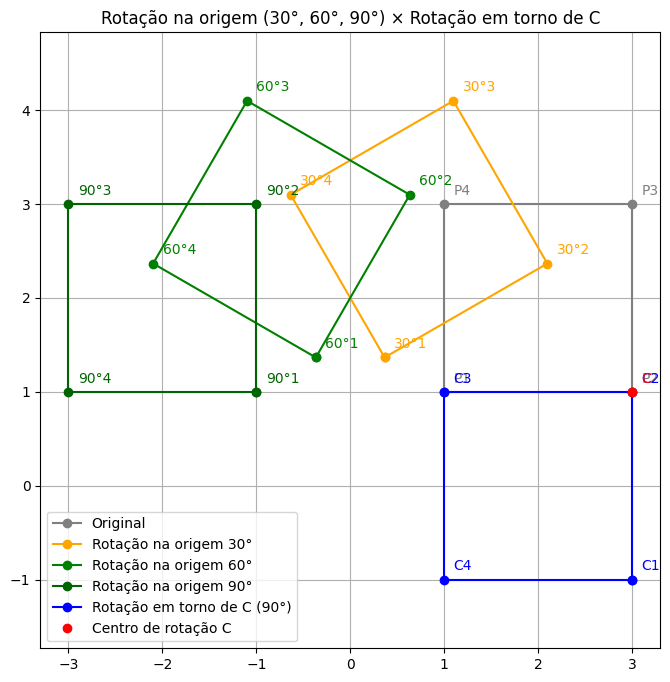

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, floatmode="maxprec_equal")

# Quadrado inicial
P = np.array([
    [1., 3., 3., 1.],
    [1., 1., 3., 3.],
    [1., 1., 1., 1.]
])

# Ponto de rotação arbitrário
xc, yc = 3.0, 1.0
theta_final = np.deg2rad(90)  # rotação final de 90°

# Rotação em torno da origem - ângulos intermediários
angles = [np.deg2rad(30), np.deg2rad(60), theta_final]

def rotation_matrix(theta):
    return np.array([
        [np.cos(theta), -np.sin(theta), 0.],
        [np.sin(theta),  np.cos(theta), 0.],
        [0., 0., 1.]
    ])

# Rotação em torno de C = (3, 1)
T_neg = np.array([
    [1., 0., -xc],
    [0., 1., -yc],
    [0., 0.,  1.]
])
T_pos = np.array([
    [1., 0., xc],
    [0., 1., yc],
    [0., 0., 1.]
])
R_final = rotation_matrix(theta_final)
M = T_pos @ (R_final @ T_neg)
P_center = M @ P

# Função para plotar quadrado com rótulos
def plot_square(P, label=None, color='b', prefix="P"):
    x = np.append(P[0, :], P[0, 0])
    y = np.append(P[1, :], P[1, 0])
    plt.plot(x, y, 'o-', color=color, label=label)
    for i in range(P.shape[1]):
        plt.text(P[0, i] + 0.1, P[1, i] + 0.1, f"{prefix}{i+1}", color=color)

# Plotagem
plt.figure(figsize=(8, 8))
plot_square(P, label="Original", color='gray', prefix="P")

# Plota rotações intermediárias na origem
colors = ['orange', 'green', 'darkgreen']
prefixes = ['30°', '60°', '90°']
for ang, color, pref in zip(angles, colors, prefixes):
    P_rot = rotation_matrix(ang) @ P
    plot_square(P_rot, label=f"Rotação na origem {pref}", color=color, prefix=pref)

# Plota rotação em torno de C
plot_square(P_center, label="Rotação em torno de C (90°)", color='blue', prefix="C")

# Marca o ponto de rotação C
plt.plot(xc, yc, 'ro', label='Centro de rotação C')
plt.text(xc + 0.1, yc + 0.1, "C", color='red')

plt.title("Rotação na origem (30°, 60°, 90°) × Rotação em torno de C")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()


## Explicação detalhada do código de rotação em torno da origem e de ponto arbitrário com etapas intermediárias

### Objetivo
O código demonstra o comportamento de uma rotação em duas situações:
1. **Rotação em torno da origem**, com visualização em ângulos intermediários $30^\circ, 60^\circ, 90^\circ$ para mostrar o caminho percorrido pelo quadrado.
2. **Rotação em torno de um ponto arbitrário $C = (3,1)$**, para comparar com a rotação na origem e evidenciar que o quadrado "gira ao redor" de $C$.

O resultado é um gráfico único contendo:
- O quadrado original.
- Três posições intermediárias do quadrado girando em torno da origem.
- A posição final do quadrado rotacionado em torno de $C$.

### Definição do quadrado
O quadrado inicial é representado por uma matriz $3 \times 4$ `P`, em coordenadas homogêneas, com cada coluna representando um vértice $[x, y, 1]^T$.  
Essa representação permite aplicar transformações em todos os vértices de uma só vez, por multiplicação matricial.

### Rotação na origem
A função `rotation_matrix(theta)` gera uma matriz de rotação $3 \times 3$ para um ângulo arbitrário $\theta$:
$$
\mathbf{R}_\theta =
\begin{bmatrix}
\cos\theta & -\sin\theta & 0 \\
\sin\theta &  \cos\theta & 0 \\
0 & 0 & 1
\end{bmatrix}
$$

A lista `angles` contém os ângulos intermediários $[30^\circ, 60^\circ, 90^\circ]$ convertidos para radianos.  
Para cada ângulo, o código calcula $P' = \mathbf{R}_\theta P$ e plota o resultado em cor diferente.  
Os rótulos usam prefixos `30°`, `60°`, `90°` para distinguir cada quadrado no gráfico.

### Rotação em torno de ponto arbitrário
Para girar em torno de $C=(x_c, y_c)$, utilizam-se três matrizes:
1. **Translação para a origem:**
$$
\mathbf{T}_{-C} =
\begin{bmatrix}
1 & 0 & -x_c \\
0 & 1 & -y_c \\
0 & 0 & 1
\end{bmatrix}
$$

2. **Rotação na origem:** $\mathbf{R}_{90}$ calculada pela função `rotation_matrix`.

3. **Translação de volta:**
$$
\mathbf{T}_{C} =
\begin{bmatrix}
1 & 0 & x_c \\
0 & 1 & y_c \\
0 & 0 & 1
\end{bmatrix}
$$

A matriz composta é obtida como:
$$
\mathbf{M} = \mathbf{T}_{C} \cdot \mathbf{R}_{90} \cdot \mathbf{T}_{-C}
$$

O produto é aplicado em `P_center = M @ P`, produzindo o quadrado rotacionado ao redor de $C$, mantendo $C$ fixo.

### Função de plotagem
A função `plot_square` recebe:
- `P`: matriz de pontos homogêneos a serem desenhados.
- `label`: nome para legenda.
- `color`: cor das linhas e marcadores.
- `prefix`: prefixo para rótulos dos vértices.

Ela conecta os pontos em ordem anti-horária e adiciona rótulos de cada vértice (por exemplo, `30°1`, `60°2`, `C3`), facilitando a comparação entre as posições.

### Visualização
O gráfico final contém:
- O quadrado original em cinza (`P1, P2, P3, P4`).
- O mesmo quadrado rotacionado em torno da origem nos ângulos intermediários:
  - Laranja para $30^\circ$ (`30°1, 30°2, ...`).
  - Verde para $60^\circ$ (`60°1, 60°2, ...`).
  - Verde escuro para $90^\circ$ (`90°1, 90°2, ...`).
- O quadrado rotacionado em torno de $C$ em azul (`C1, C2, C3, C4`).
- O ponto $C$ marcado em vermelho, mostrando o pivô de rotação.

### Interpretação didática
- A sequência de quadrados na origem ilustra a trajetória dos vértices ao longo da rotação.
- A comparação direta com a rotação em torno de $C$ deixa evidente que o resultado não é apenas uma rotação simples transladada, mas sim uma rotação ao redor de um pivô específico.
- A presença de rótulos para cada quadrado permite verificar visualmente que os vértices trocam de posição, confirmando que houve rotação e não apenas deslocamento.



---



## Mudança de Base em 2D

### Conceito de base
Em álgebra linear, uma **base** é um conjunto de vetores linearmente independentes que descrevem um sistema de coordenadas.  
No plano 2D, a base canônica é formada pelos vetores:
$$
\mathbf{e}_x =
\begin{bmatrix}1\\0\end{bmatrix},
\qquad
\mathbf{e}_y =
\begin{bmatrix}0\\1\end{bmatrix}
$$
que correspondem aos eixos cartesianos $x$ e $y$.

Um vetor qualquer $\mathbf{v}$ pode ser escrito como:
$$
\mathbf{v} = v_x \mathbf{e}_x + v_y \mathbf{e}_y
$$

### Sistema de coordenadas local e global
Em computação gráfica, frequentemente é necessário descrever pontos ou vetores em relação a diferentes sistemas de coordenadas:
- **Sistema global:** também chamado de *world space*, é o sistema fixo do mundo onde todos os objetos são posicionados.
- **Sistema local:** sistema definido em relação a um objeto, com sua própria origem e vetores base, geralmente orientados de forma diferente dos eixos globais.

### Matriz de mudança de base
Seja um sistema local definido por:
- Origem local $O_L = (x_0, y_0)$ no sistema global.
- Vetores base locais $\mathbf{u}$ e $\mathbf{v}$ expressos em coordenadas globais.

A matriz de transformação de **local para global** é:
$$
\mathbf{M}_{L \to G} =
\begin{bmatrix}
u_x & v_x & x_0 \\
u_y & v_y & y_0 \\
0   & 0   & 1
\end{bmatrix}
$$

Dado um ponto em coordenadas locais $P_L = [x_L, y_L, 1]^T$, sua posição global é:
$$
P_G = \mathbf{M}_{L \to G} P_L
$$

Para converter de **global para local**, utiliza-se a matriz inversa:
$$
P_L = \mathbf{M}_{L \to G}^{-1} P_G
$$

### Interpretação geométrica
- As colunas $u$ e $v$ definem a orientação dos eixos locais em relação ao mundo.
- O termo $(x_0, y_0)$ desloca a origem local para sua posição global.
- Essa operação é fundamental para animação hierárquica: por exemplo, quando um braço é definido em relação ao tronco, e a mão em relação ao braço, permitindo que o movimento de um nível afete os níveis dependentes.

### Exemplo numérico
**Definição do sistema local:**
- Origem local no mundo: $O_L = (2, 1)$
- Eixo local $x'$ alinhado com o vetor $\mathbf{u} = (1, 1)$ normalizado
- Eixo local $y'$ perpendicular a $\mathbf{u}$

Passo 1 – Normalizar vetores de base:
$$
\mathbf{u} = \frac{1}{\sqrt{2}}\begin{bmatrix}1\\1\end{bmatrix},
\quad
\mathbf{v} = \frac{1}{\sqrt{2}}\begin{bmatrix}-1\\1\end{bmatrix}
$$

Passo 2 – Montar matriz $M_{L \to G}$:
$$
\mathbf{M}_{L \to G} =
\begin{bmatrix}
\frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}} & 2 \\
\frac{1}{\sqrt{2}} &  \frac{1}{\sqrt{2}} & 1 \\
0 & 0 & 1
\end{bmatrix}
$$

Passo 3 – Converter um ponto local $P_L = (1,0)$:
$$
P_G = \mathbf{M}_{L \to G} P_L =
\begin{bmatrix}
\frac{1}{\sqrt{2}}\cdot 1 + 2 \\
\frac{1}{\sqrt{2}}\cdot 1 + 1 \\
1
\end{bmatrix}
=
\begin{bmatrix}
2 + 0{,}7071\\
1 + 0{,}7071\\
1
\end{bmatrix}
\Rightarrow P_G \approx (2{,}707, 1{,}707)
$$

Assim, o ponto local que está a $1$ unidade no eixo $x'$ fica na posição global $(2{,}707, 1{,}707)$.

### Conclusão
A mudança de base permite expressar vetores e pontos de um sistema de coordenadas para outro de forma consistente. Isso é indispensável para trabalhar com objetos hierárquicos, sistemas articulados, câmeras móveis e animações complexas.



Matriz local->global (M_L2G):
[[ 0.70710678 -0.70710678  2.00000000]
 [ 0.70710678  0.70710678  1.00000000]
 [ 0.00000000  0.00000000  1.00000000]]

Matriz global->local (M_G2L):
[[ 0.70710678  0.70710678 -2.12132034]
 [-0.70710678  0.70710678  0.70710678]
 [ 0.00000000  0.00000000  1.00000000]]

Pontos locais convertidos para global:
[[2.00000000 2.70710678 1.29289322 2.00000000]
 [1.00000000 1.70710678 1.70710678 2.41421356]
 [1.00000000 1.00000000 1.00000000 1.00000000]]

Pontos globais convertidos de volta para local:
[[0. 1. 0. 1.]
 [0. 0. 1. 1.]
 [1. 1. 1. 1.]]


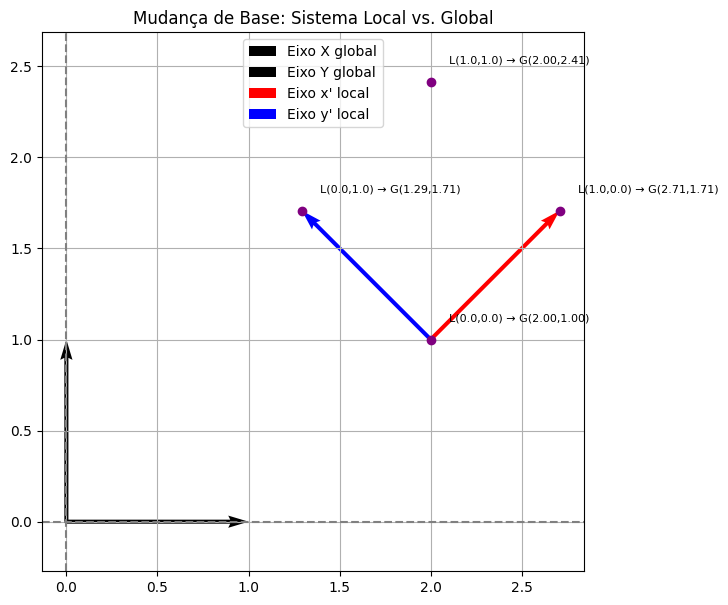

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, floatmode="maxprec_equal")

# -----------------------------------------
# Definição do sistema de coordenadas local
origin_local = np.array([2.0, 1.0])  # Origem local no sistema global

# Vetores de base locais (definidos no sistema global)
u = np.array([1.0, 1.0])   # eixo x' (não normalizado)
v = np.array([-1.0, 1.0])  # eixo y' (não normalizado)

# Normalização para garantir base ortonormal
u = u / np.linalg.norm(u)
v = v / np.linalg.norm(v)

# Matriz de mudança de base local -> global
M_L2G = np.array([
    [u[0], v[0], origin_local[0]],
    [u[1], v[1], origin_local[1]],
    [0.0,  0.0,  1.0]
])

# Matriz inversa global -> local
M_G2L = np.linalg.inv(M_L2G)

print("Matriz local->global (M_L2G):")
print(M_L2G)
print("\nMatriz global->local (M_G2L):")
print(M_G2L)

# Pontos em coordenadas locais (cantos de um quadrado no espaço local)
P_local = np.array([
    [0.0, 1.0, 0.0, 1.0],  # x_L
    [0.0, 0.0, 1.0, 1.0],  # y_L
    [1.0, 1.0, 1.0, 1.0]   # homogênea
])

# Converte para global
P_global = M_L2G @ P_local

# Converte de volta para local (teste de consistência)
P_local_recuperado = M_G2L @ P_global

print("\nPontos locais convertidos para global:")
print(P_global)

print("\nPontos globais convertidos de volta para local:")
print(P_local_recuperado)

# -----------------------------------------
# Plotagem
plt.figure(figsize=(7, 7))

# Eixos globais (linhas de referência)
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')

# Eixos globais com setas
plt.quiver(0, 0, 1, 0, angles='xy', scale_units='xy', scale=1, color='black', label='Eixo X global')
plt.quiver(0, 0, 0, 1, angles='xy', scale_units='xy', scale=1, color='black', label='Eixo Y global')  # <-- sem linestyle

# Eixos locais (em coordenadas globais)
plt.quiver(origin_local[0], origin_local[1], u[0], u[1],
           angles='xy', scale_units='xy', scale=1, color='red', label="Eixo x' local")
plt.quiver(origin_local[0], origin_local[1], v[0], v[1],
           angles='xy', scale_units='xy', scale=1, color='blue', label="Eixo y' local")

# Plota os pontos locais no sistema global
for i in range(P_local.shape[1]):
    xg, yg = P_global[0, i], P_global[1, i]
    xl, yl = P_local[0, i], P_local[1, i]
    plt.plot(xg, yg, 'o', color='purple')
    plt.text(xg + 0.1, yg + 0.1, f"L({xl},{yl}) → G({xg:.2f},{yg:.2f})", fontsize=8)

plt.title("Mudança de Base: Sistema Local vs. Global")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()


## Explicação detalhada do código de mudança de base com visualização

### Objetivo
O código implementa a mudança de base entre um sistema local e o sistema global, convertendo pontos entre os dois sistemas e mostrando visualmente como o sistema local está posicionado e orientado em relação ao global.  

### Definição do sistema local
A origem do sistema local é definida em `origin_local = (2, 1)`.  
Os vetores de base locais `u` (eixo x') e `v` (eixo y') são definidos inicialmente como vetores arbitrários no sistema global e depois normalizados para formar uma base ortonormal. A normalização é feita com `np.linalg.norm`, garantindo que os vetores tenham comprimento unitário.

### Matriz de mudança de base
A matriz `M_L2G` (local → global) é construída como:
$$
\mathbf{M}_{L \to G} =
\begin{bmatrix}
u_x & v_x & x_0 \\
u_y & v_y & y_0 \\
0   & 0   & 1
\end{bmatrix}
$$

- As duas primeiras colunas contêm as direções dos eixos locais expressos em coordenadas globais.
- A terceira coluna contém a posição da origem local no sistema global.

A matriz inversa `M_G2L` é obtida com `np.linalg.inv(M_L2G)` e realiza a transformação inversa, convertendo pontos globais de volta para coordenadas locais.

### Conversão de pontos
A matriz `P_local` contém quatro pontos de teste (cantos de um quadrado) expressos em coordenadas locais homogêneas.  
O produto matricial `P_global = M_L2G @ P_local` gera as posições globais correspondentes.  
Por consistência, os pontos globais são convertidos de volta para coordenadas locais usando `P_local_recuperado = M_G2L @ P_global`.

### Impressão dos resultados
O código imprime:
- A matriz de transformação local → global.
- A matriz inversa global → local.
- Os pontos convertidos para o sistema global.
- Os pontos recuperados em coordenadas locais, demonstrando que a transformação é reversível.

### Plotagem dos sistemas de coordenadas
A visualização utiliza `matplotlib`:
- As linhas `plt.axhline` e `plt.axvline` desenham os eixos de referência globais.
- `plt.quiver` plota setas para os eixos X e Y globais e para os eixos locais x' (vermelho) e y' (azul), mostrando a orientação do sistema local.
- Cada ponto transformado é plotado como marcador roxo. Um rótulo textual mostra as coordenadas locais originais e o resultado em coordenadas globais no formato `L(xl, yl) → G(xg, yg)`.

### Interpretação geométrica
O gráfico final mostra:
- O sistema global fixo na origem, com eixos pretos.
- O sistema local deslocado e rotacionado, com eixos vermelho e azul.
- Os pontos locais convertidos para suas posições globais, permitindo observar como a base local define uma nova orientação e origem.

Essa visualização ajuda o estudante a compreender:
- Como os vetores base e a origem local determinam a matriz de mudança de base.
- Como pontos descritos no sistema local são mapeados corretamente para o mundo.
- Como a matriz inversa recupera as coordenadas locais a partir das globais.



---



## Mini Pipeline de Transformações 2D: Model → View → Screen

### Conceito de pipeline gráfico
Em computação gráfica, a posição final de um ponto exibido na tela resulta da aplicação sequencial de transformações.  
Esse processo é conhecido como **pipeline de transformação** e normalmente é dividido em três etapas principais:

1. **Model** – Leva pontos do sistema local de um objeto para o sistema global (world space).
2. **View** – Converte pontos do sistema global para o sistema da câmera ou observador.
3. **Screen (Viewport)** – Mapeia coordenadas da câmera para coordenadas de tela ou janela de visualização.

Cada etapa é representada por uma matriz de transformação $3 \times 3$ em coordenadas homogêneas, e a posição final de cada vértice é obtida por multiplicação matricial:

$$
P_{\text{screen}} = \mathbf{M}_{\text{screen}} \cdot \mathbf{M}_{\text{view}} \cdot \mathbf{M}_{\text{model}} \cdot P_{\text{local}}
$$

### Etapa 1 – Model
A matriz **Model** (M) converte pontos do espaço local de um objeto para o espaço global.  
Ela pode incluir:
- Escalas para dimensionar o objeto.
- Rotações para orientá-lo no mundo.
- Translações para posicioná-lo na cena.

Exemplo genérico:
$$
\mathbf{M}_{\text{model}} =
\begin{bmatrix}
s_x \cos\theta & -s_y \sin\theta & t_x \\
s_x \sin\theta & s_y \cos\theta  & t_y \\
0 & 0 & 1
\end{bmatrix}
$$

### Etapa 2 – View
A matriz **View** (V) reposiciona e reorienta a cena em relação ao observador.  
No caso 2D, uma câmera pode ser representada por sua posição $(x_c, y_c)$ e ângulo de orientação $\phi$.  
A transformação view realiza:
1. Translação para mover a câmera para a origem.
2. Rotação inversa para alinhar o eixo da câmera ao eixo global.

$$
\mathbf{M}_{\text{view}} = \mathbf{R}_{-\phi} \cdot \mathbf{T}_{-C}
$$

Assim, os pontos passam a ser descritos no sistema de coordenadas da câmera.

### Etapa 3 – Screen (Viewport)
A matriz **Screen** ou **Viewport** (S) converte as coordenadas normalizadas do sistema da câmera para coordenadas de tela.  
No caso 2D, pode-se considerar:
- Uma escala para ajustar o tamanho da cena à janela de visualização.
- Uma translação para centralizar ou alinhar a cena.

Exemplo:
$$
\mathbf{M}_{\text{screen}} =
\begin{bmatrix}
s_w & 0 & x_{\text{offset}} \\
0 & s_h & y_{\text{offset}} \\
0 & 0 & 1
\end{bmatrix}
$$

### Exemplo numérico
**Problema:**  
- Objeto definido no espaço local: quadrado de lado $1$ com origem em $(0,0)$.
- Model: escalar por $2$ e transladar para $(3, 1)$.
- View: câmera posicionada em $(2,0)$ olhando para cima ($\phi = 90^\circ$).
- Screen: janela de 10×10, convertendo coordenadas para a faixa [0,10] × [0,10].

Passo 1 – Model
$$
\mathbf{M}_{\text{model}} =
\begin{bmatrix}
2 & 0 & 3 \\
0 & 2 & 1 \\
0 & 0 & 1
\end{bmatrix}
$$

Passo 2 – View (translação e rotação de -90°)
$$
\mathbf{M}_{\text{view}} =
\begin{bmatrix}
0 & 1 & 0 \\
-1 & 0 & 2 \\
0 & 0 & 1
\end{bmatrix}
$$

Passo 3 – Screen (escala 1:1 e deslocamento para alinhar com tela)
$$
\mathbf{M}_{\text{screen}} =
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1
\end{bmatrix}
$$

Matriz composta:
$$
\mathbf{M}_{\text{total}} = \mathbf{M}_{\text{screen}} \cdot \mathbf{M}_{\text{view}} \cdot \mathbf{M}_{\text{model}}
$$

Aplicando em cada vértice $P_{\text{local}}$, obtêm-se as coordenadas finais de exibição na tela.

### Interpretação didática
Esse encadeamento ilustra claramente a separação de responsabilidades:
- **Model** controla o objeto individualmente.
- **View** controla a câmera ou o ponto de vista.
- **Screen** controla a forma como a cena é mapeada para o espaço de exibição.

A utilização de matrizes permite compor todas as transformações em uma única matriz global antes de aplicar aos vértices, economizando processamento e garantindo consistência.



=== Local (pontos de entrada) ===
Vértices (cartesianos):
P1 = (0.0, 0.0)
P2 = (1.0, 0.0)
P3 = (1.0, 1.0)
P4 = (0.0, 1.0)

=== Model (local → world) ===
Matriz:
[[2. 0. 3.]
 [0. 2. 1.]
 [0. 0. 1.]]
Vértices (cartesianos):
P1 = (3.0, 1.0)
P2 = (5.0, 1.0)
P3 = (5.0, 3.0)
P4 = (3.0, 3.0)

=== View (world → camera) ===
Matriz:
[[ 0.  1. -0.]
 [-1.  0.  2.]
 [ 0.  0.  1.]]
Vértices (cartesianos):
P1 = (1.0, -1.0)
P2 = (1.0, -3.0)
P3 = (3.0000000000000004, -3.0)
P4 = (3.0, -1.0)

=== Screen (camera → viewport 10x10) ===
Matriz:
[[ 5.  0. -5.]
 [ 0.  5. 15.]
 [ 0.  0.  1.]]
Vértices (cartesianos):
P1 = (0.0, 10.0)
P2 = (0.0, 0.0)
P3 = (10.0, 0.0)
P4 = (9.999999999999996, 10.0)

=== Composição total ===
M_total = M_screen @ M_view @ M_model
[[  0.  10.   0.]
 [-10.   0.  10.]
 [  0.   0.   1.]]
Norma máx. da diferença entre aplicação em etapas e composta: 1.7763568394002505e-15


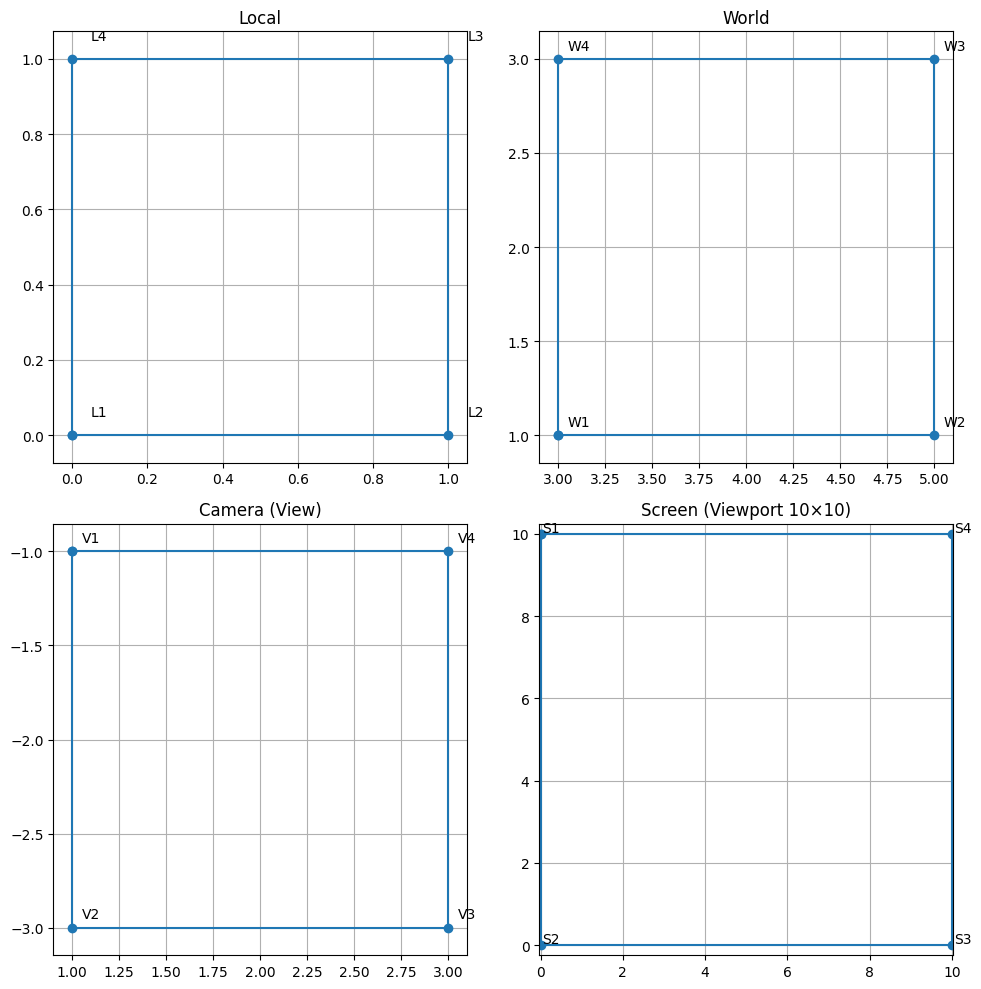

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, floatmode="maxprec_equal", linewidth=120)

# ------------------------------------------------------------
# Convenções
# - Pontos são colunas de uma matriz 3xN em coordenadas homogêneas.
# - Aplicação: P' = M @ P
# ------------------------------------------------------------

def square_local():
    """Quadrado unitário no espaço local, com vértices (0,0),(1,0),(1,1),(0,1) em ordem anti-horária."""
    return np.array([
        [0., 1., 1., 0.],
        [0., 0., 1., 1.],
        [1., 1., 1., 1.]
    ])

def print_stage(title, M, Pin, Pout):
    print(f"\n=== {title} ===")
    if M is not None:
        print("Matriz:")
        print(M)
    print("Vértices (cartesianos):")
    cart = (Pout[:2, :] / Pout[2, :]).T
    for i, (x, y) in enumerate(cart, start=1):
        print(f"P{i} = ({x}, {y})")

def plot_poly(ax, P, title="", prefix="P"):
    """Plota polígono fechado definido por P (3xN), rotulando vértices com prefixo."""
    x = np.append(P[0, :], P[0, 0])
    y = np.append(P[1, :], P[1, 0])
    ax.plot(x, y, 'o-')
    for i in range(P.shape[1]):
        ax.text(P[0, i] + 0.05, P[1, i] + 0.05, f"{prefix}{i+1}")
    ax.set_title(title)
    ax.axis('equal')
    ax.grid(True)

# ------------------------------------------------------------
# 1) Espaço LOCAL: quadrado unitário
# ------------------------------------------------------------
P_local = square_local()
print_stage("Local (pontos de entrada)", None, P_local, P_local)

# ------------------------------------------------------------
# 2) MODEL: escalar por 2 e transladar para (3,1)
#    M_model = T(3,1) @ S(2,2)
# ------------------------------------------------------------
S = np.array([[2., 0., 0.],
              [0., 2., 0.],
              [0., 0., 1.]])
T = np.array([[1., 0., 3.],
              [0., 1., 1.],
              [0., 0., 1.]])
M_model = T @ S
P_world = M_model @ P_local
print_stage("Model (local → world)", M_model, P_local, P_world)

# ------------------------------------------------------------
# 3) VIEW: câmera em C=(2,0) com orientação φ=90° (olhando para +y do mundo)
#    M_view = R(-φ) @ T(-C)
# ------------------------------------------------------------
phi = np.deg2rad(90.0)

R_minus_phi = np.array([[ np.cos(-phi), -np.sin(-phi), 0.],
                        [ np.sin(-phi),  np.cos(-phi), 0.],
                        [ 0.,            0.,           1.]])
T_minus_C = np.array([[1., 0., -2.],
                      [0., 1.,  0.],
                      [0., 0.,  1.]])
M_view = R_minus_phi @ T_minus_C
P_view = M_view @ P_world
print_stage("View (world → camera)", M_view, P_world, P_view)

# ------------------------------------------------------------
# 4) SCREEN: viewport 10x10
#    M_screen = S_viewport @ T_to_origin
#    Onde T_to_origin leva o bbox de P_view para a origem
#    e S_viewport escala para caber em [0,10]x[0,10] (sem margem)
# ------------------------------------------------------------
xv = P_view[0, :] / P_view[2, :]
yv = P_view[1, :] / P_view[2, :]
min_x, max_x = xv.min(), xv.max()
min_y, max_y = yv.min(), yv.max()
range_x = max_x - min_x if max_x > min_x else 1.0
range_y = max_y - min_y if max_y > min_y else 1.0

# Escalas para ajustar exatamente no viewport [0,10]
vp_w = 10.0
vp_h = 10.0
sx = vp_w / range_x
sy = vp_h / range_y

T_to_origin = np.array([[1., 0., -min_x],
                        [0., 1., -min_y],
                        [0., 0.,  1.   ]])
S_viewport = np.array([[sx, 0., 0.],
                       [0., sy, 0.],
                       [0., 0., 1.]])

M_screen = S_viewport @ T_to_origin
P_screen = M_screen @ P_view
print_stage("Screen (camera → viewport 10x10)", M_screen, P_view, P_screen)

# ------------------------------------------------------------
# 5) Matriz COMPOSTA total: M_total = M_screen @ M_view @ M_model
#    Verificação de consistência
# ------------------------------------------------------------
M_total = M_screen @ (M_view @ M_model)
P_screen_check = M_total @ P_local

print("\n=== Composição total ===")
print("M_total = M_screen @ M_view @ M_model")
print(M_total)

# Conferência numérica
diff = np.max(np.abs(P_screen_check - P_screen))
print(f"Norma máx. da diferença entre aplicação em etapas e composta: {diff}")

# ------------------------------------------------------------
# 6) PLOT: Local, World, View, Screen (4 painéis)
# ------------------------------------------------------------
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

plot_poly(axs[0, 0], P_local,  title="Local",  prefix="L")
plot_poly(axs[0, 1], P_world,  title="World",  prefix="W")
plot_poly(axs[1, 0], P_view,   title="Camera (View)", prefix="V")
plot_poly(axs[1, 1], P_screen, title="Screen (Viewport 10×10)", prefix="S")

# Em Viewport, limitar o eixo em [0,10] para evidenciar o mapeamento
axs[1, 1].set_xlim(0, 10)
axs[1, 1].set_ylim(0, 10)

plt.tight_layout()
plt.show()


# Explicação detalhada do código: pipeline 2D Model → View → Screen

## 1. Objetivo e visão geral

O código implementa, calcula e visualiza o pipeline de transformações em 2D, levando um polígono do espaço local do objeto até a tela. As etapas são model, view e screen. Em coordenadas homogêneas, a posição final é dada por
$$
P_{\text{screen}} = \mathbf{M}_{\text{screen}}\,\mathbf{M}_{\text{view}}\,\mathbf{M}_{\text{model}}\,P_{\text{local}},
$$
com $P$ representado como matriz $3\times N$ cujas colunas são vértices $[x,y,1]^T$, e cada $\mathbf{M}$ uma matriz $3\times 3$.

## 2. Convenções e estruturas do código

Os pontos são colunas em uma matriz $3\times N$. A aplicação de uma transformação é feita como $P'=\mathbf{M}\,P$. A função `square_local` cria o quadrado unitário no espaço local com vértices $(0,0),(1,0),(1,1),(0,1)$. A função `print_stage` imprime, para cada etapa, a matriz usada e os vértices em coordenadas cartesianas. A função `plot_poly` desenha o polígono, fecha o contorno e rotula os vértices, mantendo proporção com `axis('equal')`.

## 3. Etapa Model: local → world

A etapa model move o objeto do seu sistema local para o sistema global. No código, a model é composta por uma escala uniforme $s_x=s_y=2$ seguida de uma translação $(t_x,t_y)=(3,1)$. A matriz composta é
$$
\mathbf{M}_{\text{model}}=\mathbf{T}(3,1)\,\mathbf{S}(2,2)=
\begin{bmatrix}
1&0&3\\
0&1&1\\
0&0&1
\end{bmatrix}
\begin{bmatrix}
2&0&0\\
0&2&0\\
0&0&1
\end{bmatrix}.
$$
Pelo formalismo $P'=\mathbf{M}P$, a transformação mais à direita é aplicada primeiro. Assim, primeiro ocorre a escala e depois a translação. O resultado $P_{\text{world}}=\mathbf{M}_{\text{model}}\,P_{\text{local}}$ posiciona o quadrado ampliado no mundo.

Interpretação. A submatriz $2\times 2$ de $\mathbf{S}$ altera comprimentos no objeto. A coluna de translação em $\mathbf{T}$ desloca a origem do objeto no mundo. A ordem é relevante porque $\mathbf{T}\,\mathbf{S}\neq \mathbf{S}\,\mathbf{T}$ em geral.

## 4. Etapa View: world → camera

A etapa view reexpressa a cena no sistema da câmera. A câmera está em $C=(2,0)$ com orientação $\varphi=90^\circ$. Para levar o mundo ao sistema da câmera, primeiro translada-se o mundo por $-C$ e depois aplica-se a rotação inversa da câmera, isto é,
$$
\mathbf{M}_{\text{view}}=\mathbf{R}(-\varphi)\,\mathbf{T}(-C).
$$
Com $\varphi=90^\circ$, vale $\cos(-90^\circ)=0$ e $\sin(-90^\circ)=-1$, logo
$$
\mathbf{R}(-90^\circ)=
\begin{bmatrix}
0&1&0\\
-1&0&0\\
0&0&1
\end{bmatrix}.
$$
A translação $\mathbf{T}(-C)$ move a câmera para a origem do sistema da câmera. A rotação $\mathbf{R}(-\varphi)$ alinha o eixo da câmera com os eixos canônicos. O resultado é $P_{\text{view}}=\mathbf{M}_{\text{view}}\,P_{\text{world}}$.

Interpretação. O operador view transforma do espaço do mundo para o espaço da câmera. É a inversa do pose da câmera, por isso usa rotação de ângulo negativo e translação negativa.

## 5. Etapa Screen: camera → viewport

A etapa screen mapeia coordenadas da câmera para a janela de visualização $[0,10]\times[0,10]$. O código calcula o retângulo envolvente de $P_{\text{view}}$ e monta duas matrizes
$$
\mathbf{T}_{\text{to\_origin}}=
\begin{bmatrix}
1&0&-x_{\min}\\
0&1&-y_{\min}\\
0&0&1
\end{bmatrix},
\qquad
\mathbf{S}_{\text{viewport}}=
\begin{bmatrix}
s_x&0&0\\
0&s_y&0\\
0&0&1
\end{bmatrix},
$$
onde $s_x=\tfrac{10}{x_{\max}-x_{\min}}$ e $s_y=\tfrac{10}{y_{\max}-y_{\min}}$. Primeiro desloca-se o retângulo para a origem, depois escala-se para preencher $[0,10]$ em cada eixo. A composição
$$
\mathbf{M}_{\text{screen}}=\mathbf{S}_{\text{viewport}}\,\mathbf{T}_{\text{to\_origin}}
$$
gera $P_{\text{screen}}=\mathbf{M}_{\text{screen}}\,P_{\text{view}}$.

Observações. Se $x_{\max}=x_{\min}$ ou $y_{\max}=y_{\min}$, o código protege contra divisão por zero usando intervalo unitário. O mapeamento utiliza escalas independentes em $x$ e $y$. Caso a preservação de proporção seja um requisito, escolhe-se $s=\min\{s_x,s_y\}$ e centra-se o conteúdo no viewport, o que não é realizado aqui por opção didática.

## 6. Composição total e checagem numérica

A composição global é calculada como
$$
\mathbf{M}_{\text{total}}=\mathbf{M}_{\text{screen}}\,\mathbf{M}_{\text{view}}\,\mathbf{M}_{\text{model}}.
$$
O código verifica que aplicar as três etapas em sequência ou aplicar $\mathbf{M}_{\text{total}}$ diretamente ao $P_{\text{local}}$ resulta no mesmo $P_{\text{screen}}$, calculando a norma máxima da diferença. Eventuais diferenças residuais decorrem apenas de arredondamentos numéricos em ponto flutuante.

## 7. Visualização das quatro etapas

São gerados quatro painéis. Local mostra o quadrado no espaço do objeto. World exibe o quadrado já escalado e posicionado no mundo. Camera apresenta a mesma geometria nas coordenadas da câmera após $\mathbf{M}_{\text{view}}$. Screen mostra o resultado final no viewport $[0,10]\times[0,10]$ após $\mathbf{M}_{\text{screen}}$. Em cada painel os vértices são rotulados e a grade auxilia na leitura geométrica. Em Screen, os limites dos eixos são fixados em $[0,10]$ para evidenciar o mapeamento.

## 8. Relação com a teoria

A formulação em coordenadas homogêneas permite representar, com matrizes $3\times 3$, todas as transformações afins necessárias no pipeline. A etapa model concentra transformações específicas do objeto, como escala, rotação e posicionamento. A etapa view implementa a mudança de referência do mundo para a câmera, utilizando a inversa do pose da câmera. A etapa screen realiza o mapeamento da região de interesse no espaço da câmera para o espaço de exibição, aqui implementado por normalização via retângulo envolvente e reescala para a janela. A associatividade da multiplicação matricial permite acumular as etapas em uma única matriz composta, reduzindo o custo por vértice e mantendo consistência geométrica.

## 9. Extensões usuais

O mesmo esquema se estende a cenários com vários objetos por meio de diferentes matrizes model, mantendo uma única view compartilhada pela câmera. Em pipelines 3D, adiciona-se a transformação de projeção antes do mapeamento para a tela e a dimensão homogênea passa a quatro componentes, mas a lógica de composição permanece análoga.



---

